# 02 - Feature engineering and leakage control
Code: `src/churn/feature_engineering.py`.

> **At a glance**
> * One row per **member x quarterly snapshot**: features from the 6 months up to the cutoff, label from the 3 months
>   after it. Five snapshots: three training quarters (labels rebuilt), the official test quarter (the given
>   `CHURNED`), and one scoring quarter (future unknown).
> * 36 features in 4 groups: demographics (8), behavioural (14), engagement (10), support (4).
> * A leakage test rebuilds every snapshot from data truncated at its cutoff: **no feature changes** (maximum
>   difference 0.0).

In [1]:
%matplotlib inline
from churn.notebook import *   # pandas as pd, numpy as np, display, Markdown, fig(), tab(), run_step(), paths P

## 1. Snapshot design

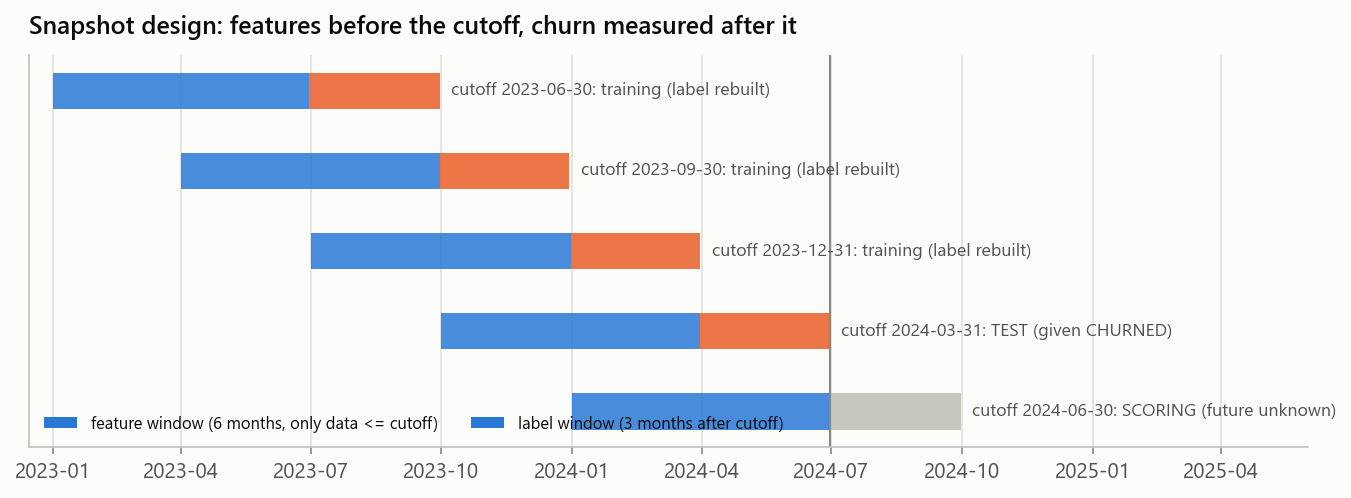

,cutoff,label_window,eligible_members,churn_rate_all,active_members,churn_rate_active,lapsed_members,churn_rate_lapsed,role
0,2023-06-30,Jul 2023 +3 months,1787,0.181869,1624,0.102833,163,0.969325,training (label rebuilt)
1,2023-09-30,Oct 2023 +3 months,1980,0.245455,1655,0.100302,325,0.984615,training (label rebuilt)
2,2023-12-31,Jan 2024 +3 months,2167,0.301338,1681,0.102320,486,0.989712,training (label rebuilt)
3,2024-03-31,Apr 2024 +3 months,2368,0.343328,1715,0.095627,653,0.993874,test (given CHURNED)
4,2024-06-30,Jul 2024 +3 months,2474,NaN,1657,NaN,817,NaN,scoring (future unknown)


In [2]:
fig("eda_timeline", 1000)
tab("snapshots_target_distribution")

**What does this show?** The feature window (blue, only data up to the cutoff) and label window (orange, the next 3 months) of each snapshot.

**Why is it relevant?** This is how the model will be used: on the last day of a quarter, score every member for the next quarter.

**What did we learn?** Only one quarter has the given label. Rebuilding the same label for three earlier quarters (99.65% agreement where both exist) gives honest out-of-time training data whose label windows all end before the test cutoff.

**What does it imply?** Training on earlier quarters and testing on Apr-Jun 2024 mimics deployment; no random split is needed.

## 2. Feature catalogue

In [3]:
tab("feature_catalogue")

,feature,group,type,definition,business_interpretation,leakage_control,mean_abs_lr_contribution_active,rank_lr_active,mean_abs_shap_active,used_in_final_model
0,AGE,demographics,numeric,age from the profile,life stage,static attribute,0.022,35,0.036,yes
1,GENDER,demographics,categorical,gender ('Unknown' if missing),demographic segment,static attribute,0.059,29,0.002,yes
2,CITY,demographics,categorical,home city (cleaned casing),regional differences,static attribute,0.184,18,0.055,yes
3,MEMBERSHIP_TIER,demographics,categorical,Silver / Gold / Platinum,does tier protect against churn?,static attribute,0.110,25,0.004,yes
4,MARKETING_OPT_IN,demographics,binary,opted in to marketing,reachable by email campaigns,static attribute,0.401,7,0.042,yes
5,PREFERRED_CATEGORY,demographics,categorical,preferred shopping category,shopping mission,static attribute,0.166,21,0.007,yes
6,HOME_STORE_PRICE_TIER,demographics,categorical,price tier of the home store,price positioning of the store,static attribute,0.180,20,0.023,yes
7,tenure_months,demographics,numeric,months from signup to cutoff,loyalty length,uses cutoff date only,0.063,28,0.024,yes
8,recency_months,behavioural,numeric,"months since the last purchase month, capped at 6",how long since they last shopped,months <= cutoff only,0.388,8,0.570,yes
9,no_purchase_6m,behavioural,binary,no purchase in the 6 months to the cutoff,already lapsed,months <= cutoff only,0.059,30,0.000,yes


Design choices:
* **Fixed windows** (3 and 6 months) and recency capped at 6 months, so the first snapshot (6 months of history) and
  the last (15 months) produce comparable features.
* **Trends** (last 3 months minus the 3 before) capture fading, which the EDA showed is the key pattern.
* **Missing months are unknown, not zero.** A month without a row is a deleted record (gap) if the member has a later
  row up to the cutoff; otherwise it is inactivity. That decision uses rows up to the cutoff only.
* **Usefulness** columns come from the fitted models (mean absolute logistic contribution and LightGBM SHAP); the
  ablation in notebook 04 tests the groups formally.

## 3. Leakage test

In [4]:
tab("leakage_check")

,cutoff,members,activity_rows_removed,features_compared,max_abs_difference,missing_value_mismatches,categorical_mismatches,passed
0,2023-06-30,1947,18975,36,0.0,0,0,True
1,2023-09-30,2149,14315,36,0.0,0,0,True
2,2023-12-31,2353,9572,36,0.0,0,0,True
3,2024-03-31,2549,4760,36,0.0,0,0,True


For each labelled snapshot the features are rebuilt after deleting **every activity row after the cutoff** (up to
18,975 rows). If any feature had looked into the future, directly or through the gap-vs-inactivity decision, the values
would change. None does. In addition, the code asserts that the label table's post-outcome columns are never in the
feature list.

## 4. The modelling dataset (deliverable)

In [5]:
ds = pd.read_csv(P.processed / "customer_modelling_dataset.csv")
print(ds.shape)
display(ds.groupby("snapshot").agg(members=("CUSTOMER_ID", "size"), churn_rate=("churn", "mean"),
                                   active_share=("active_at_cutoff", "mean")).round(3))
ds.head()

(10776, 45)


,members,churn_rate,active_share
snapshot,,,
2023-06-30,1787,0.182,0.909
2023-09-30,1980,0.245,0.836
2023-12-31,2167,0.301,0.776
2024-03-31,2368,0.343,0.724
2024-06-30,2474,NaN,0.670


,CUSTOMER_ID,eligible,recency_months,no_purchase_6m,months_since_any_activity,txn_avg_3m,txn_avg_6m,txn_trend,spend_avg_3m,spend_avg_6m,spend_trend,basket_avg_6m,active_share_6m,cats_avg_3m,promo_pct_avg_6m,gap_months_6m,history_months,app_avg_3m,app_avg_6m,app_trend,...,coupon_trend,tickets_avg_3m,tickets_avg_6m,tickets_trend,complaint_6m,AGE,GENDER,CITY,MEMBERSHIP_TIER,MARKETING_OPT_IN,PREFERRED_CATEGORY,HOME_STORE_PRICE_TIER,PREFERRED_STORE_ID,tenure_months,signup_cohort,active_at_cutoff,population,cutoff,churn,snapshot
0,500001,True,0.0,0,0.0,4.666667,4.166667,1.000000,116.540000,97.118333,38.843333,23.291667,1.0,2.666667,0.158333,0,6,3.000000,2.333333,1.333333,...,0.666667,0.000000,0.166667,-0.333333,0,36.0,F,Madison,Silver,1,Frozen Foods,Value,140,10.4,2022,True,active (bought in last 3 months),2023-06-30,0.0,2023-06-30
1,500003,True,0.0,0,0.0,6.500000,5.200000,2.166667,210.150000,160.410000,82.900000,30.390000,1.0,5.000000,0.356000,1,6,5.500000,3.600000,3.166667,...,0.333333,0.000000,0.000000,0.000000,0,53.0,Unknown,Tulsa,Gold,0,Frozen Foods,Mainstream,119,27.0,2021,True,active (bought in last 3 months),2023-06-30,0.0,2023-06-30
2,500004,True,0.0,0,0.0,5.666667,5.500000,0.333333,139.640000,131.903333,15.473333,23.531667,1.0,5.000000,0.251667,0,6,2.333333,2.833333,-1.000000,...,0.000000,0.666667,0.500000,0.333333,1,52.0,F,Spokane,Gold,1,Snacks,Upscale,106,23.7,2021,True,active (bought in last 3 months),2023-06-30,0.0,2023-06-30
3,500006,True,0.0,0,0.0,3.666667,3.166667,1.000000,121.493333,99.558333,43.870000,31.723333,1.0,2.333333,0.253333,0,6,3.000000,2.333333,1.333333,...,0.000000,0.333333,0.166667,0.333333,0,44.0,F,Nashville,Silver,0,Snacks,Upscale,128,9.5,2022,True,active (bought in last 3 months),2023-06-30,0.0,2023-06-30
4,500007,True,0.0,0,0.0,4.000000,2.500000,3.000000,136.223333,86.471667,99.503333,35.411667,1.0,3.666667,0.290000,0,6,1.666667,1.500000,0.333333,...,-0.333333,0.000000,0.000000,0.000000,0,39.0,F,Tulsa,Platinum,1,Frozen Foods,Mainstream,116,26.0,2021,True,active (bought in last 3 months),2023-06-30,0.0,2023-06-30
